In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import math
import seaborn as sns


In [2]:
df = pd.read_csv("FourRegionData.csv")
df.head(10)

,Region,Year,Month,SoilTemperature-10,SoilTemperature-30,SoilTemperature-50,Rainfall,Temperature,Min Temperature,Max Temperature,Humidity,Sunshine,Wind Speed,Surface Pressure,Solar Radiation
0,2,2001,1,17.40,18.81,19.43,0,18.38,13.04,25.44,62.68,7.94,2.17,101268.29,199.25
1,2,2001,2,19.88,19.98,20.36,1,22.61,16.90,28.56,61.71,7.19,1.98,101039.08,210.73
2,2,2001,3,24.08,23.32,23.17,33,26.62,20.73,31.84,55.48,8.75,2.10,100882.56,251.75
3,2,2001,4,27.62,27.02,26.77,46,29.06,24.71,32.06,65.63,8.55,2.70,100655.40,257.46
4,2,2001,5,28.54,28.29,28.21,402,27.69,24.18,32.09,77.39,6.10,2.37,100234.63,172.32
5,2,2001,6,30.11,29.82,29.64,386,28.03,25.55,31.75,83.17,3.51,3.64,99934.18,140.45
6,2,2001,7,30.74,30.53,30.64,202,28.83,25.92,31.60,80.26,4.55,3.87,99991.05,169.40
7,2,2001,8,30.99,30.99,30.86,205,29.46,25.23,31.50,82.19,5.15,3.01,100129.68,181.66
8,2,2001,9,29.83,29.89,29.95,209,28.71,24.34,32.42,82.53,4.65,2.14,100499.17,170.22
9,2,2001,10,28.00,28.29,28.50,177,27.63,22.83,31.44,80.45,5.60,1.59,100864.38,167.89


In [4]:
df.describe()

,Region,Year,Month,SoilTemperature-10,SoilTemperature-30,SoilTemperature-50,Rainfall,Temperature,Min Temperature,Max Temperature,Humidity,Sunshine,Wind Speed,Surface Pressure,Solar Radiation
count,1056.00000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000
mean,4.50000,2011.500000,6.500000,27.048911,26.753002,26.674479,147.833333,25.855767,21.290057,30.597367,78.353949,5.755464,2.292803,100662.094602,188.207803
std,1.80363,6.347295,3.453688,4.535854,4.141530,3.841275,160.693275,4.215597,5.181553,4.226878,7.316262,1.891709,0.583342,528.956442,32.363212
min,2.00000,2001.000000,1.000000,16.100000,17.370000,17.640000,0.000000,14.120000,8.360000,3.810000,52.100000,0.000000,1.240000,99447.650000,107.480000
25%,3.50000,2006.000000,3.750000,23.340000,23.312500,23.307500,7.000000,22.712500,16.972500,28.887500,74.175000,4.537500,1.830000,100185.972500,165.687500
50%,4.50000,2011.500000,6.500000,28.895000,28.235000,27.950000,96.000000,27.760000,23.315000,31.995000,80.000000,5.900000,2.160000,100683.545000,181.160000
75%,5.50000,2017.000000,9.250000,30.830000,30.142500,29.832500,242.500000,29.120000,25.922500,33.160000,83.732500,7.070000,2.692500,101156.590000,208.437500
max,7.00000,2022.000000,12.000000,34.130000,33.890000,33.310000,849.000000,32.100000,30.420000,38.460000,93.840000,20.350000,4.280000,101603.720000,288.600000


In [5]:
df.columns

Index(['Region', 'Year', 'Month', 'SoilTemperature-10', 'SoilTemperature-30',
       'SoilTemperature-50', 'Rainfall', 'Temperature', 'Min Temperature',
       'Max Temperature', 'Humidity', 'Sunshine', 'Wind Speed',
       'Surface Pressure', 'Solar Radiation'],
      dtype='object')

In [6]:
df.shape

(1056, 15)

## We remove all the outlier using capping method 
### The columns on where we used capping : Humidity,Solar Radiation, Sunshine,Rainfall,Max Temperature

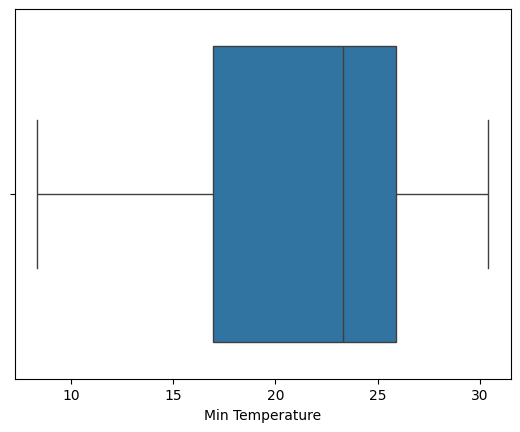

In [6]:
sns.boxplot(x=df['Min Temperature'])
plt.show()

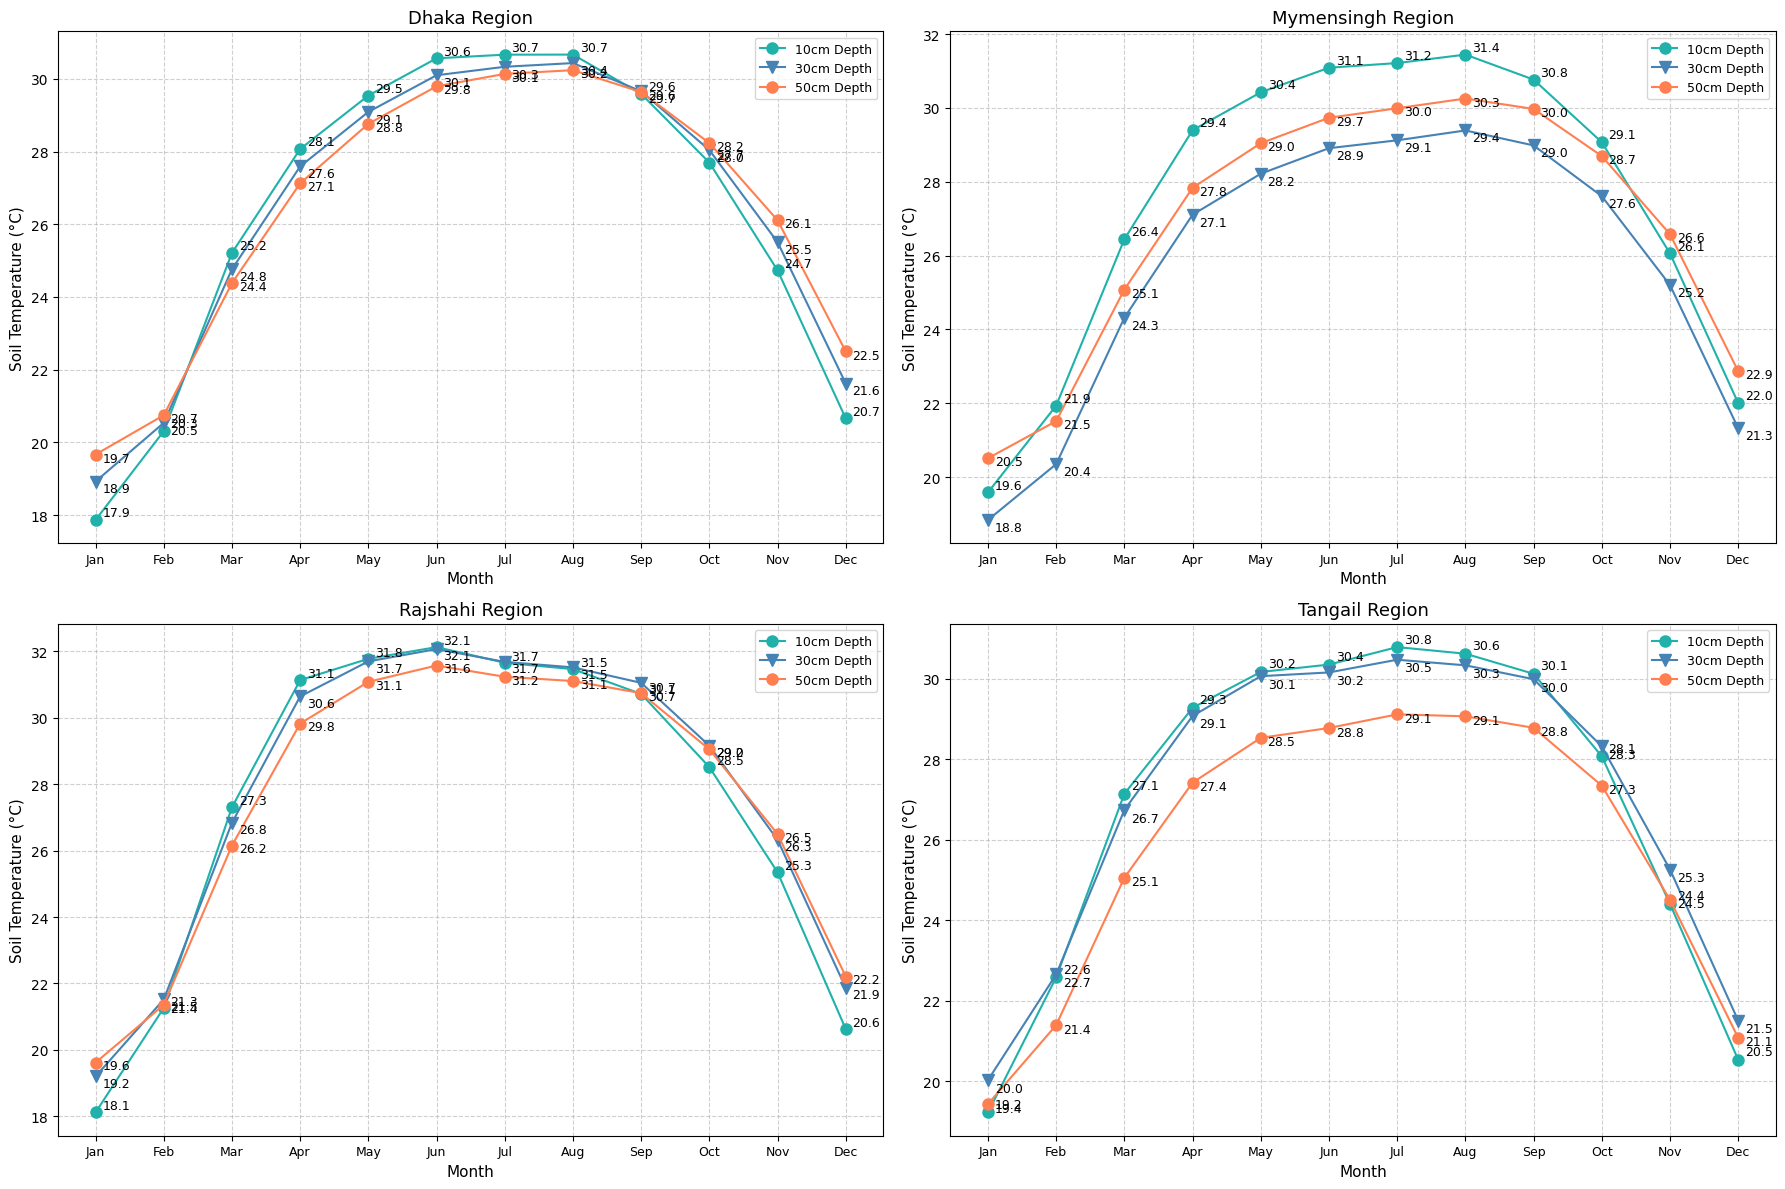

In [6]:

from matplotlib.ticker import FixedLocator

data = pd.read_csv('FourRegionData.csv')

regions = [2, 4, 5, 7]
region_names = {
    2: "Dhaka Region",
    4: "Mymensingh Region",
    5: "Rajshahi Region",
    7: "Tangail Region"
}

plot_series = [
    {
        'data_col': 'SoilTemperature-10',
        'color': 'lightseagreen',
        'marker': 'o',
        'label': '10cm Depth',
        'offset_y': 0.2,
        'offset_x': 0.1,
    },
    {
        'data_col': 'SoilTemperature-30',
        'color': 'steelblue',
        'marker': 'v',
        'label': '30cm Depth',
        'offset_y': -0.2,
        'offset_x': 0.1,
    },
    {
        'data_col': 'SoilTemperature-50',
        'color': 'coral',
        'marker': 'o',
        'label': '50cm Depth',
        'offset_y': -0.1,
        'offset_x': 0.1,
    },
]


fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.flatten()

for idx, region in enumerate(regions):
    df = data[data['Region'] == region]
    monthly_avg_temp = df.groupby('Month')[
        ['SoilTemperature-10', 'SoilTemperature-30', 'SoilTemperature-50']
    ].mean().reset_index()

    ax = axs[idx]
    
    for series in plot_series:
        ax.plot(
            monthly_avg_temp['Month'],
            monthly_avg_temp[series['data_col']],
            color=series['color'],
            marker=series['marker'],
            linestyle='-',
            markersize=8,
            label=series['label']
        )

        for i, txt in enumerate(monthly_avg_temp[series['data_col']]):
            ax.text(
                monthly_avg_temp['Month'][i] + series['offset_x'],
                txt + series['offset_y'],
                f'{txt:.1f}',
                fontsize=9,
                color='black',
                ha='left',
                va='center',
            )

    ax.set_title( f'{region_names[region]}', fontsize=13)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Soil Temperature (°C)', fontsize=11)
    ax.xaxis.set_major_locator(FixedLocator(range(1, 13)))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Monthly Soil Temperature by Regions.png', dpi=300)
plt.show()


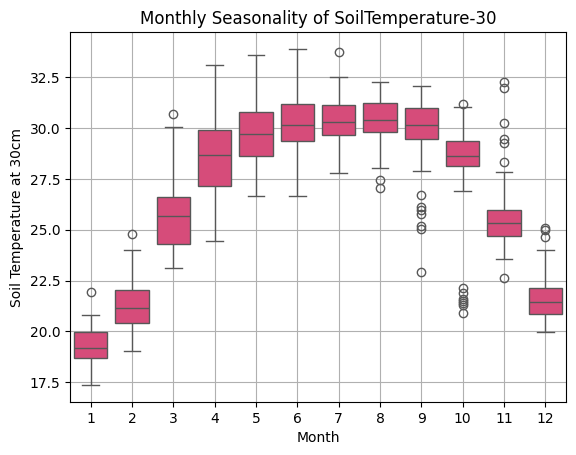

In [21]:
import seaborn as sns

sns.boxplot(x='Month', y='SoilTemperature-30', data=df,color="#ed3572")
plt.title('Monthly Seasonality of SoilTemperature-30')
plt.xlabel('Month')
plt.ylabel('Soil Temperature at 30cm')
plt.grid(True)
plt.show()


In [3]:
from sklearn.metrics import r2_score

# --- Preprocessing ---
features = df[['Month', 'Temperature', 'Min Temperature',
               'Max Temperature', 'Surface Pressure']]
target = df['SoilTemperature-50']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# --- Sliding Window Function ---
def create_sliding_window(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# --- Loop over different window sizes ---
histories=[]
comparisons={}
window_sizes = [3, 6, 9, 12]
for WINDOW in window_sizes:
    print(f"\n======================")
    print(f"🔁 Training with WINDOW SIZE: {WINDOW}")
    print(f"======================")

    # Create windowed sequences
    X_seq, y_seq = create_sliding_window(X_scaled, y_scaled, WINDOW)

    # Split the data
    total_samples = len(X_seq)
    train_end = int(0.7 * total_samples)
    val_end = int(0.85 * total_samples)

    X_train, y_train = X_seq[:train_end], y_seq[:train_end]
    X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
    X_test, y_test = X_seq[val_end:], y_seq[val_end:]

    # --- Model Definition ---
    model = Sequential([
      LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
      Dropout(0.2),
      LSTM(32, return_sequences=True),
      Dropout(0.2),
      LSTM(32, return_sequences=False),
      Dense(64, activation='relu'),
      Dropout(0.2),
      Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    # --- Callbacks ---
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f'best_model_window_{WINDOW}.h5', monitor='val_loss', save_best_only=True, mode='min')
    lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    # --- Train the Model ---
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, checkpoint, lr_sched],
        verbose=0
    )
    histories.append(history.history)
    # --- Evaluate ---
    results = model.evaluate(X_test, y_test, verbose=0)
    loss = results[0]
    mae = results[1]
    print(f"✅ Test Loss (MSE): {loss:.4f}")
    print(f"✅ Test MAE:       {mae:.4f}")

    # --- Predict and Compare ---
    predictions = model.predict(X_test)
    predictions_rescaled = target_scaler.inverse_transform(predictions)
    y_test_rescaled = target_scaler.inverse_transform(y_test.reshape(-1, 1))
    # === 📊 Extra Evaluation Metrics ===
    y_true = y_test_rescaled.flatten()
    y_pred = predictions_rescaled.flatten()
    y_mean = np.mean(y_true)
    # MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # R²
    r2 = r2_score(y_true, y_pred)

    # sMAPE
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

    # NSE
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_mean) ** 2)

    # Willmott's d-index
    d_index = 1 - (np.sum((y_true - y_pred) ** 2) /
                   np.sum((np.abs(y_pred - y_mean) + np.abs(y_true - y_mean)) ** 2))

    # ✅ Print all metrics
    print(f"✅RMSE:       {np.sqrt(loss):.3f}")
    print(f"✅ MAPE:     {mape:.2f}%")
    print(f"✅ R²:       {r2:.4f}")
    print(f"✅ sMAPE:    {smape:.2f}%")
    print(f"✅ NSE:      {nse:.4f}")
    print(f"✅ d-index:  {d_index:.4f}")   
    comparison = pd.DataFrame({
        'Predicted': y_pred.flatten(),
        'Actual': y_true.flatten()
    })
    comparisons[WINDOW] = comparison
    print("\nSample Predictions:")
    print(comparison.head())



🔁 Training with WINDOW SIZE: 3





C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Test Loss (MSE): 0.0081
✅ Test MAE:       0.0731
5/5 [==============================] - 1s 3ms/step
✅RMSE:       0.090
✅ MAPE:     4.73%
✅ R²:       0.8429
✅ sMAPE:    4.56%
✅ NSE:      0.8429
✅ d-index:  0.9595

Sample Predictions:
   Predicted  Actual
0  25.601074   24.51
1  22.658495   20.39
2  20.055357   19.28
3  21.694613   22.01
4  25.319077   26.51

🔁 Training with WINDOW SIZE: 6


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Test Loss (MSE): 0.0122
✅ Test MAE:       0.0948
5/5 [==============================] - 1s 5ms/step
✅RMSE:       0.111
✅ MAPE:     6.10%
✅ R²:       0.7635
✅ sMAPE:    5.84%
✅ NSE:      0.7635
✅ d-index:  0.9403

Sample Predictions:
   Predicted  Actual
0  26.288136   24.51
1  22.933735   20.39
2  20.255873   19.28
3  22.271030   22.01
4  25.586121   26.51

🔁 Training with WINDOW SIZE: 9


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Test Loss (MSE): 0.0116
✅ Test MAE:       0.0945
5/5 [==============================] - 1s 4ms/step
✅RMSE:       0.108
✅ MAPE:     5.96%
✅ R²:       0.7766
✅ sMAPE:    5.74%
✅ NSE:      0.7766
✅ d-index:  0.9465

Sample Predictions:
   Predicted  Actual
0  25.389267   24.51
1  21.882263   20.39
2  19.954805   19.28
3  22.203835   22.01
4  25.809277   26.51

🔁 Training with WINDOW SIZE: 12


C:\Users\HP Laptop 15\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Test Loss (MSE): 0.0105
✅ Test MAE:       0.0878
5/5 [==============================] - 1s 6ms/step
✅RMSE:       0.102
✅ MAPE:     5.57%
✅ R²:       0.7982
✅ sMAPE:    5.37%
✅ NSE:      0.7982
✅ d-index:  0.9517

Sample Predictions:
   Predicted  Actual
0  21.851551   20.39
1  19.568819   19.28
2  21.008076   22.01
3  25.671515   26.51
4  28.786123   29.13


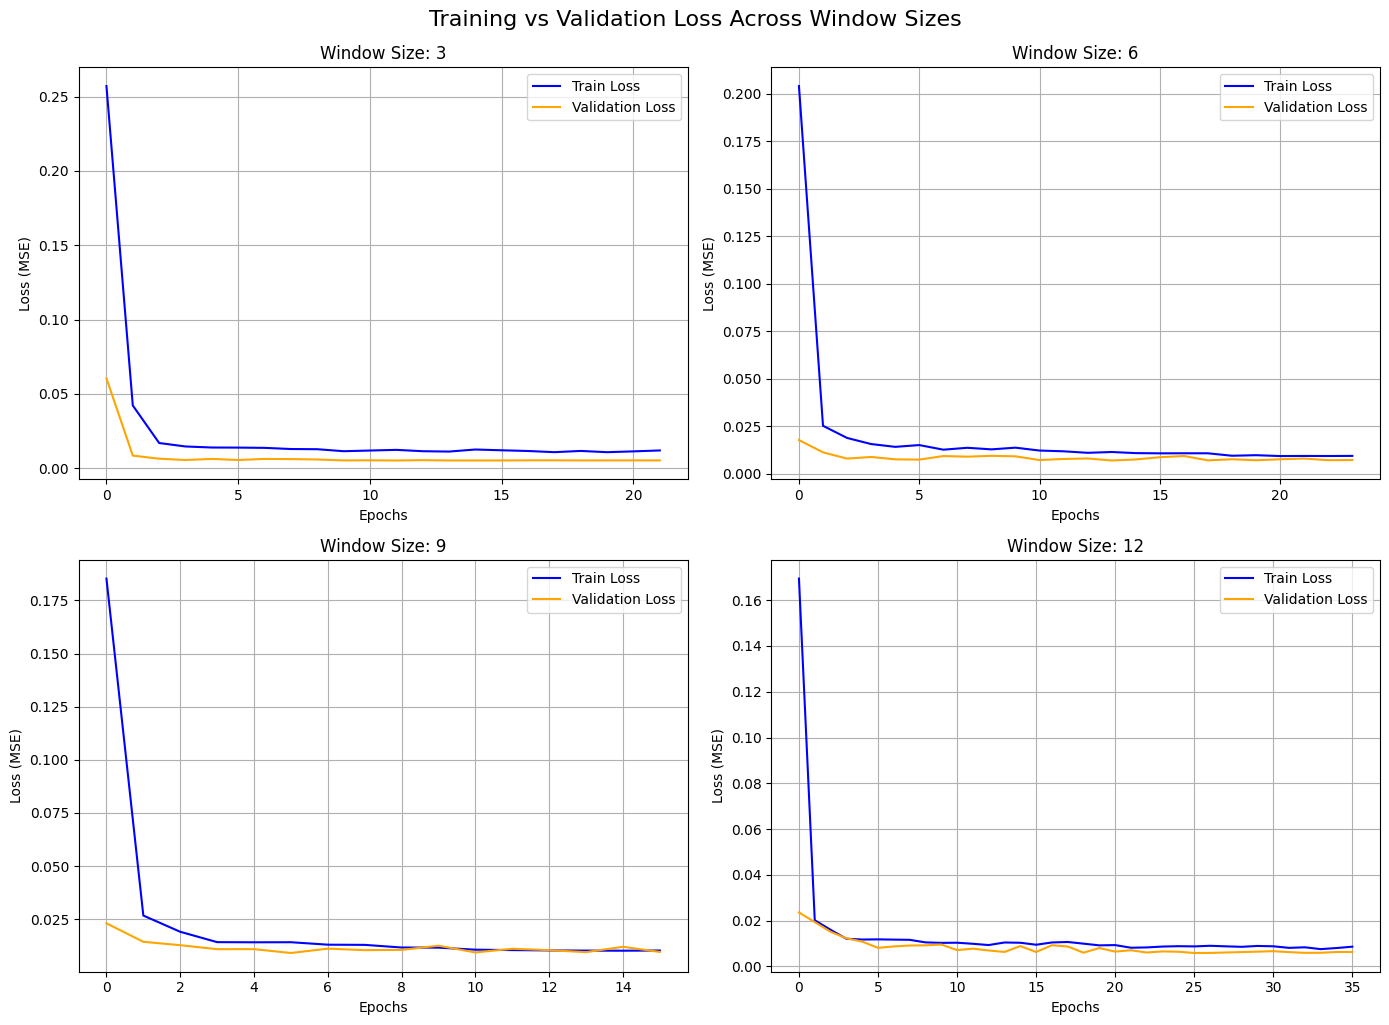

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, hist in enumerate(histories):
    window = window_sizes[i]
    ax = axes[i]
    ax.plot(hist['loss'], label='Train Loss', color='blue')
    ax.plot(hist['val_loss'], label='Validation Loss', color='orange')
    ax.set_title(f'Window Size: {window}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (MSE)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.suptitle('Training vs Validation Loss Across Window Sizes', fontsize=16, y=1.02)
plt.show()

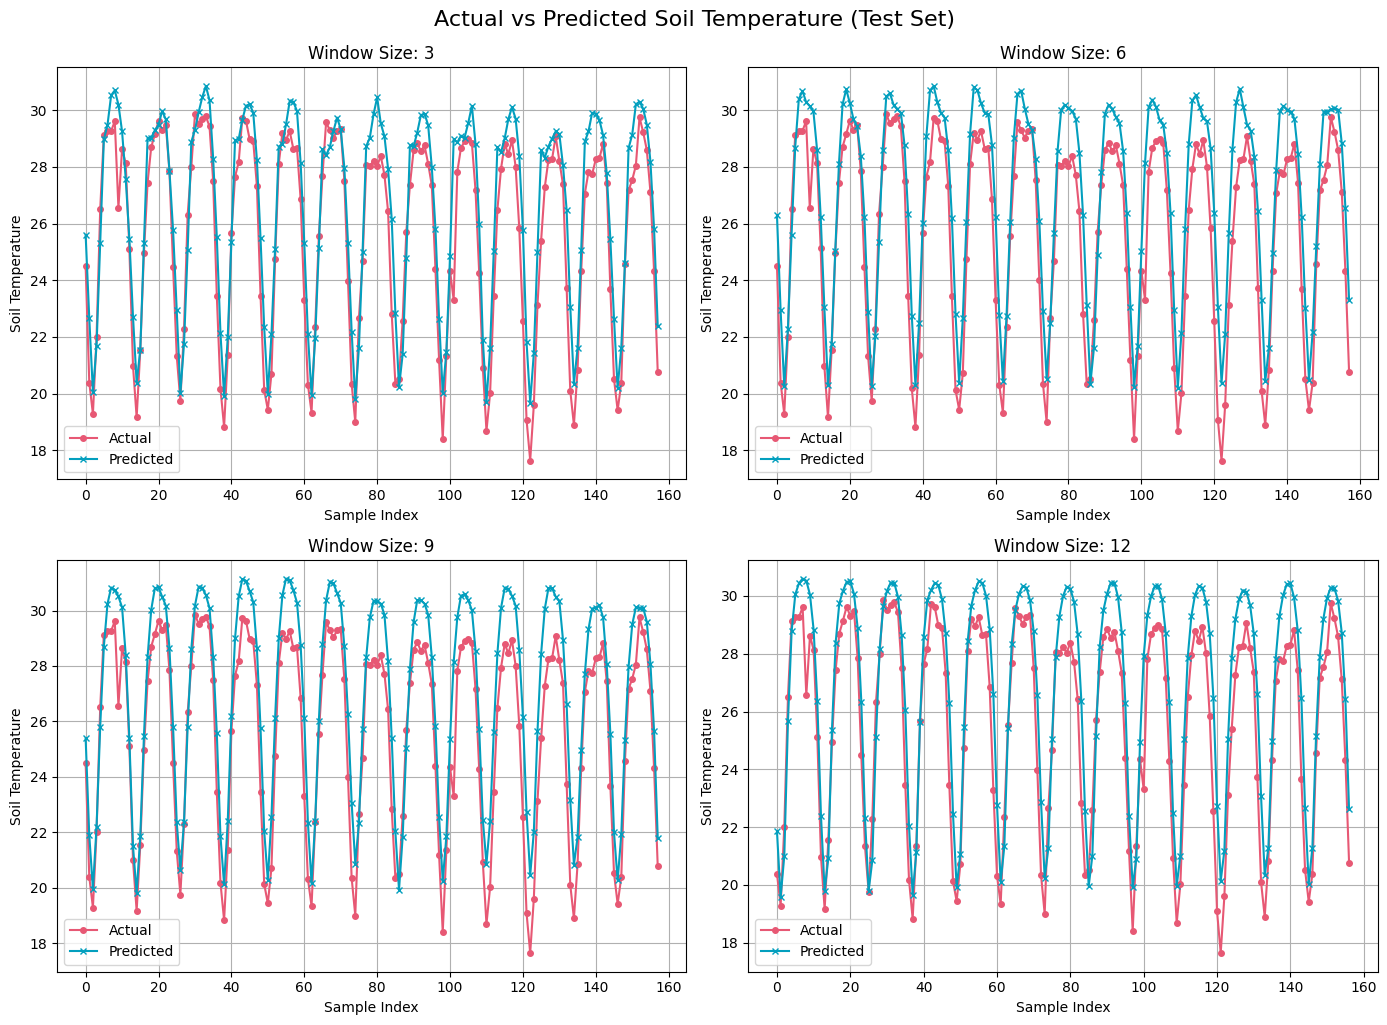

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, window in enumerate(window_sizes):
    ax = axes[i]
    comparison = comparisons[window]
    ax.plot(comparison['Actual'].values, label='Actual', marker='o', color='#e75874', markersize=4)
    ax.plot(comparison['Predicted'].values, label='Predicted', marker='x', color='#039fbe', markersize=4)
    ax.set_title(f'Window Size: {window}')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Soil Temperature')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.suptitle('Actual vs Predicted Soil Temperature (Test Set)', fontsize=16, y=1.02)
plt.show()